# Zadanie 1
Rozwiązanie problemu XOR za pomocą regresji logistycznej

In [9]:
!pip install optuna

In [10]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import optuna

In [11]:
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y_or = np.array([0,1,1,1])
y_xor = np.array([0,1,1,0])

In [12]:
model_or = LogisticRegression().fit(X,y_or)
model_xor = LogisticRegression().fit(X,y_xor)

In [13]:
print(model_or.predict(np.array([[1,0],[0,1],[0,0],[1,1]])))
print(model_xor.predict(np.array([[1,0],[0,1],[0,0],[1,1]])))

[1 1 1 1]
[0 0 0 0]


# Zadanie 2
Implementacja perceptronu z aktywacją sigmoidalną do separacji liniowo-separowalnych
klas


In [14]:
import torch
from torch import nn
import torch.optim as optim

In [15]:
class Perceptron(nn.Module):
  def __init__(self):
    super(Perceptron, self).__init__()
    self.linearf = nn.Linear(2,1)
    self.sigmoid = nn.Sigmoid()
  def forward(self, x):
    x = self.linearf(x)
    x = self.sigmoid(x)
    return x


In [16]:
def train_model(model, inputs, targets, epochs=2000):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

    return model

In [17]:
X_t = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float)
y_or_t = torch.tensor([[0],[1],[1],[1]],dtype=torch.float)
y_xor_t = torch.tensor([[0],[1],[1],[0]],dtype=torch.float)

In [18]:
model_or = Perceptron()
model_xor = Perceptron()

In [19]:
train_model(model_or, X_t, y_or_t)
train_model(model_xor, X_t, y_xor_t)

Perceptron(
  (linearf): Linear(in_features=2, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [20]:
model_or.eval()
model_xor.eval()
with torch.no_grad():
  print(np.array(model_or(X_t)>=0.5,dtype=int))
  print(np.array(model_xor(X_t)>=0.5, dtype=int))

[[0]
 [1]
 [1]
 [1]]
[[1]
 [1]
 [1]
 [1]]


# Zadanie 3
 Rozwiązanie problemu XOR za pomocą MLP

In [21]:
class PerceptronMLP(nn.Module):
    def __init__(self):
        super(PerceptronMLP, self).__init__()
        self.fc1 = nn.Linear(2, 4)
        self.fc2 = nn.Linear(4, 1)
        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x) #  Dla głębszych ReLu
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

In [22]:
model_mlp_xor = PerceptronMLP()
train_model(model_mlp_xor, X_t, y_xor_t)

PerceptronMLP(
  (fc1): Linear(in_features=2, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=1, bias=True)
  (sigmoid): Sigmoid()
  (relu): ReLU()
)

In [23]:
with torch.no_grad():
  print(np.array(model_mlp_xor(X_t)>=0.5,dtype=int))

[[0]
 [1]
 [1]
 [0]]


In [30]:
xx, yy = np.meshgrid(np.linspace(0,1,100), np.linspace(0,1,100))
grid = np.c_[xx.ravel(), yy.ravel()]
XY_tensor = torch.tensor(grid, dtype=torch.float32)

tensor([[0.0000, 0.0000],
        [0.0101, 0.0000],
        [0.0202, 0.0000],
        ...,
        [0.9798, 1.0000],
        [0.9899, 1.0000],
        [1.0000, 1.0000]])

In [36]:
import matplotlib.pyplot as plt

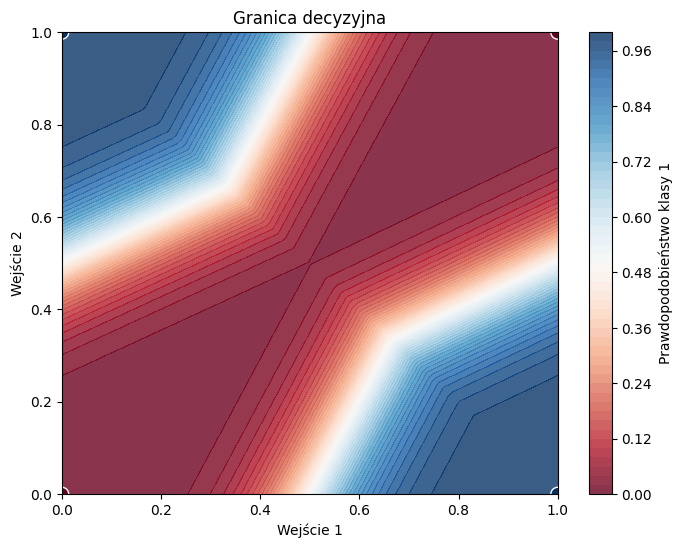

In [39]:
with torch.no_grad():
  preds = model_mlp_xor(XY_tensor)
  Z = preds.reshape(xx.shape).numpy()

plt.figure(figsize=(8, 6))
contour = plt.contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.8)
plt.colorbar(contour, label='Prawdopodobieństwo klasy 1')

# Opcjonalnie: nałożenie punktów treningowych (np. dla XOR)
X_train = np.array([[0,0], [0,1], [1,0], [1,1]])
Y_train = np.array([0, 1, 1, 0])
plt.scatter(X_train[:, 0], X_train[:, 1], c=Y_train, edgecolors='white', s=100, cmap='RdBu')

plt.title("Granica decyzyjna")
plt.xlabel("Wejście 1")
plt.ylabel("Wejście 2")
plt.show()